In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
        # Apply label encoding for binary columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
import warnings
import joblib
import pickle
# Bỏ qua toàn bộ cảnh báo
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print(df.shape)
print(df.dtypes)

(918, 12)
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [4]:
X= df.drop(columns= 'HeartDisease')
y= df['HeartDisease']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [6]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(642, 11) (642,)
(276, 11) (276,)


In [7]:
df.isnull().sum().sort_values(ascending=False)/len(df)

Age               0.0
Sex               0.0
ChestPainType     0.0
RestingBP         0.0
Cholesterol       0.0
FastingBS         0.0
RestingECG        0.0
MaxHR             0.0
ExerciseAngina    0.0
Oldpeak           0.0
ST_Slope          0.0
HeartDisease      0.0
dtype: float64

In [8]:
cat_features= X.select_dtypes(include= 'object')
numerical_features=X.select_dtypes(include = ['int64', 'float64'])
for index, col in enumerate (cat_features):
    
    print(col, cat_features.iloc[:, index].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


In [9]:
numeric_cols= list(numerical_features.columns)
print(numeric_cols)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


(642, 18)
['RestingBP', 'Cholesterol', 'Age', 'MaxHR', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'Sex', 'ExerciseAngina', 'FastingBS']
Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Preprocessor saved as preprocessor.pkl
Model saved using XGBoost's save_model as xgboost_heart_disease_model.pth
Model saved using pickle as xgboost_heart_disease_model.pkl
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost Accuracy: 0.8478260869565217

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       112
           1       0.91      0.82      0.87       164

    accuracy                           0.85       276
   macro avg       0.84      0.85      0.85       276
weighted avg       0.86      0.85      

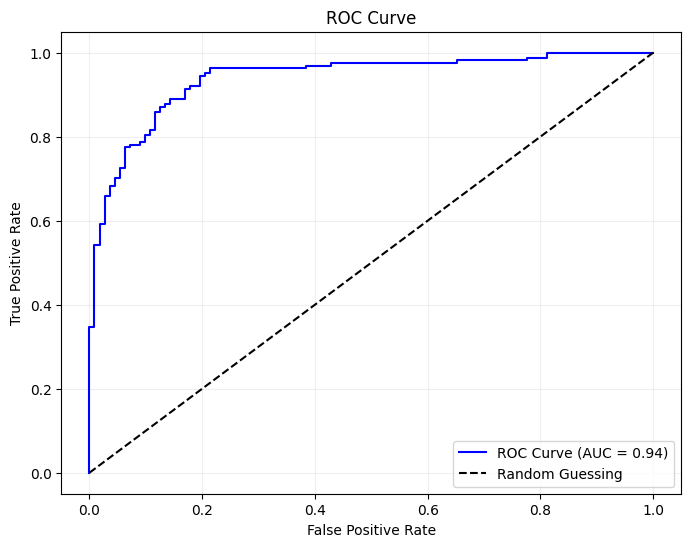

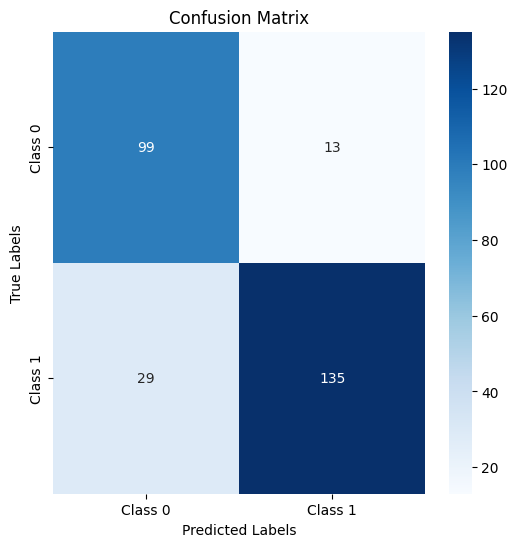

In [10]:
# Define Preprocessor class
class Preprocessor:
    def __init__(self, num_rest_attribs, num_missvalue_attribs, cat_nominal_attribs, cat_binary_attribs):
        self.num_rest_attribs = num_rest_attribs  # Numerical columns without missing values
        self.num_missvalue_attribs = num_missvalue_attribs  # Numerical columns with missing values
        self.cat_nominal_attribs = cat_nominal_attribs  # Categorical columns (OneHotEncoder)
        self.cat_binary_attribs = cat_binary_attribs  # Binary categorical columns (OrdinalEncoder)
        self.prep_pipeline = None

    def fit_transform(self, X):
        # Define pipeline for numerical columns with missing values
        num_imputer_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy="median", missing_values=0)),  # Replace 0 with median
            ('scaler', StandardScaler())  # Standardize numerical data
        ])

        # Define pipeline for numerical columns without missing values
        num_scaler_pipeline = Pipeline([
            ('scaler', StandardScaler())
        ])

        # Define pipeline for nominal categorical columns
        cat_nominal_pipeline = Pipeline([
            ('onehot', OneHotEncoder(handle_unknown="ignore"))
        ])

        # Define pipeline for binary categorical columns
        cat_binary_pipeline = Pipeline([
            ('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ])

        # Combine all transformers into a ColumnTransformer
        combine_transformers = ColumnTransformer(
            transformers=[
                ("num_missvalue", num_imputer_pipeline, self.num_missvalue_attribs),
                ("num_rest", num_scaler_pipeline, self.num_rest_attribs),
                ("cat_nominal", cat_nominal_pipeline, self.cat_nominal_attribs),
                ("cat_binary", cat_binary_pipeline, self.cat_binary_attribs),
            ],
            remainder='passthrough',
            verbose_feature_names_out=False
        )

        # Build the full pipeline
        self.prep_pipeline = Pipeline(steps=[
            ('preprocessor', combine_transformers)
        ])

        # Fit and transform the data
        transformed_data = self.prep_pipeline.fit_transform(X)
        return transformed_data

    def transform(self, X):
        """Transform the input data using the fitted pipeline."""
        # Transform data
        transformed_data = self.prep_pipeline.transform(X)
        return transformed_data

    def get_feature_names(self):
        """Retrieve feature names after transformation."""
        return list(self.prep_pipeline.named_steps['preprocessor'].get_feature_names_out())


# Define column groups
num_rest_attribs = ['Age', 'MaxHR', 'Oldpeak']
num_missvalue_attribs = ['RestingBP', 'Cholesterol']
cat_nominal_attribs = ['ChestPainType', 'RestingECG', 'ST_Slope']
cat_binary_attribs = ['Sex', 'ExerciseAngina']

# Preprocess data
prep = Preprocessor(num_rest_attribs, num_missvalue_attribs, cat_nominal_attribs, cat_binary_attribs)
X_train_preprocessed = prep.fit_transform(X_train)
X_test_preprocessed = prep.transform(X_test)
print(X_train_preprocessed.shape)
print(prep.get_feature_names())
# XGBoost with GridSearch
xgb_model = XGBClassifier(enable_categorical=True)
xgb_param_grid = {
    'n_estimators': [5, 10, 20, 50 ,100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [1e-4, 1e-3, 1e-2, 0.1,1], 
    'subsample': [0.5, 0.7, 0.8, 1.0]
}
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring='accuracy', verbose=1)
xgb_grid.fit(X_train_preprocessed, y_train)


# XGBoost Results
xgb_best_model = xgb_grid.best_estimator_
xgb_predictions = xgb_best_model.predict(X_test_preprocessed)

# Save the model using XGBoost's native save_model method

preprocessor_path = "preprocessor.pkl"
with open(preprocessor_path, "wb") as file:
    pickle.dump(prep, file)
print(f"Preprocessor saved as {preprocessor_path}")

xgboost_native_model_path = "xgboost_heart_disease_model.pth"
xgb_best_model.save_model(xgboost_native_model_path)
print(f"Model saved using XGBoost's save_model as {xgboost_native_model_path}")

# Save the model using joblib for compatibility with scikit-learn
pickle_model_path = "xgboost_heart_disease_model.pkl"
with open(pickle_model_path, "wb") as file:
    pickle.dump(xgb_best_model, file)
print(f"Model saved using pickle as {pickle_model_path}")


xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Best Params: {xgb_grid.best_params_}")
print(f"XGBoost Accuracy: {xgb_accuracy}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, xgb_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

# ROC-AUC Score and Curve
if len(set(y_test)) == 2:  # Ensure binary classification
    y_pred_proba = xgb_best_model.predict_proba(X_test_preprocessed)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nROC-AUC Score: {roc_auc}")

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="blue")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    roc_curve_path = "roc_curve.png"
    plt.savefig(roc_curve_path)
    print(f"ROC Curve saved as {roc_curve_path}")
    plt.show()
# Vẽ Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [11]:
!pip install scikeras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 76.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


Fitting 3 folds for each of 18 candidates, totalling 54 fits
NN Best Params: {'model__num_nodes_layer1': 32, 'model__num_nodes_layer2': 8, 'model__optimizer': 'adam'}
Neural Network model saved as best_nn_model.pkl
NN Accuracy: 0.7934782608695652
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.75      0.75       112
           1       0.83      0.82      0.83       164

    accuracy                           0.79       276
   macro avg       0.79      0.79      0.79       276
weighted avg       0.79      0.79      0.79       276


Confusion Matrix:
[[ 84  28]
 [ 29 135]]

ROC-AUC Score: 0.8855074041811847
ROC Curve saved as roc_curve_nn.png


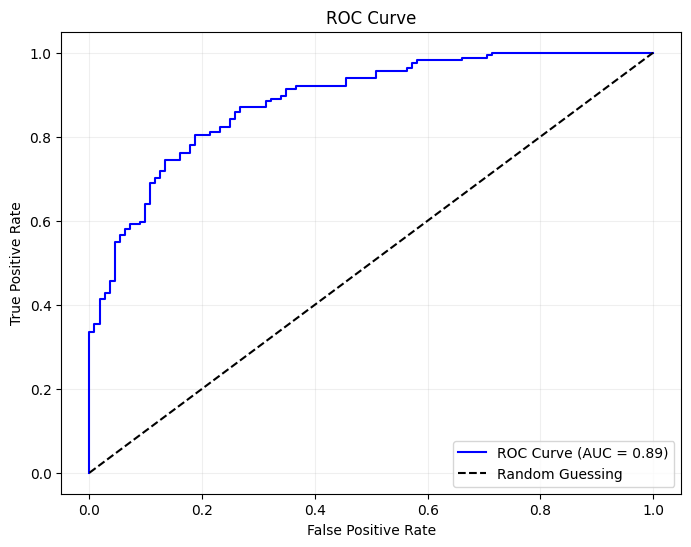

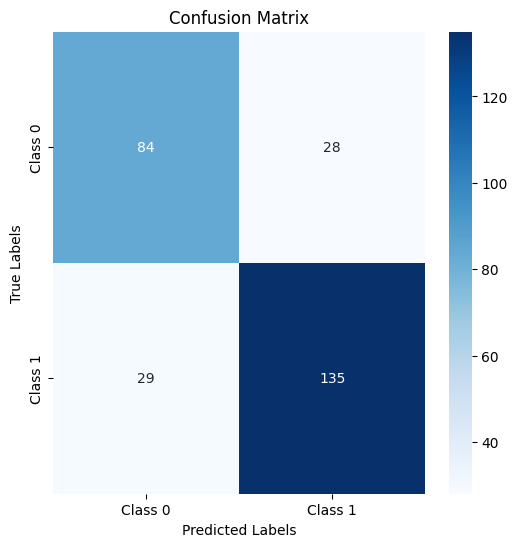

In [12]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import GridSearchCV

# Define the neural network with dynamic number of nodes in each layer
def create_nn(optimizer='adam', num_nodes_layer1=32, num_nodes_layer2=32):
    model = Sequential()
    model.add(Dense(num_nodes_layer1, input_dim=X_train_preprocessed.shape[1], activation='relu'))  # Layer 1
    model.add(Dense(num_nodes_layer2, activation='relu'))  # Layer 2
    model.add(Dense(1, activation='sigmoid'))  # Output layer
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrap the model with SciKerasClassifier
nn_model = KerasClassifier(
    model=create_nn,
    verbose=0,
    epochs = 5
)

# Define hyperparameter grid
nn_param_grid = {
    'model__optimizer': ['adam', 'sgd'],  # Optimizers to try
    'model__num_nodes_layer1': [8, 16, 32 ],  # Number of nodes in Layer 1
    'model__num_nodes_layer2': [8, 16, 32],  # Number of nodes in Layer 2
}

# Perform GridSearchCV
nn_grid = GridSearchCV(estimator=nn_model, param_grid=nn_param_grid, cv=3, scoring='accuracy', verbose=1)
nn_grid.fit(X_train_preprocessed, y_train)

# Neural Network Results
nn_best_model = nn_grid.best_estimator_
print(f"NN Best Params: {nn_grid.best_params_}")
# Save the best neural network model
nn_model_path = "best_nn_model.pkl"
with open(nn_model_path, "wb") as file:
    pickle.dump(nn_best_model, file)
print(f"Neural Network model saved as {nn_model_path}")

# Dự đoán trên tập test
y_pred = nn_best_model.predict(X_test_preprocessed)

# Đánh giá độ chính xác
nn_accuracy = accuracy_score(y_test, y_pred)
print(f"NN Accuracy: {nn_accuracy}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# ROC-AUC Score and Curve
if len(set(y_test)) == 2:  # Ensure binary classification
    y_pred_proba = nn_best_model.predict_proba(X_test_preprocessed)[:, 1]  # Probabilities of positive class
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nROC-AUC Score: {roc_auc}")

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="blue")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    roc_curve_path = "roc_curve_nn.png"
    plt.savefig(roc_curve_path)
    print(f"ROC Curve saved as {roc_curve_path}")
    plt.show()

# Vẽ Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.5}
XGBoost Accuracy (Raw Data): 0.8913043478260869

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.87       112
           1       0.95      0.87      0.90       164

    accuracy                           0.89       276
   macro avg       0.89      0.90      0.89       276
weighted avg       0.90      0.89      0.89       276


Confusion Matrix:
[[104   8]
 [ 22 142]]

ROC-AUC Score: 0.9516006097560975
ROC Curve saved as roc_curve_nn.png


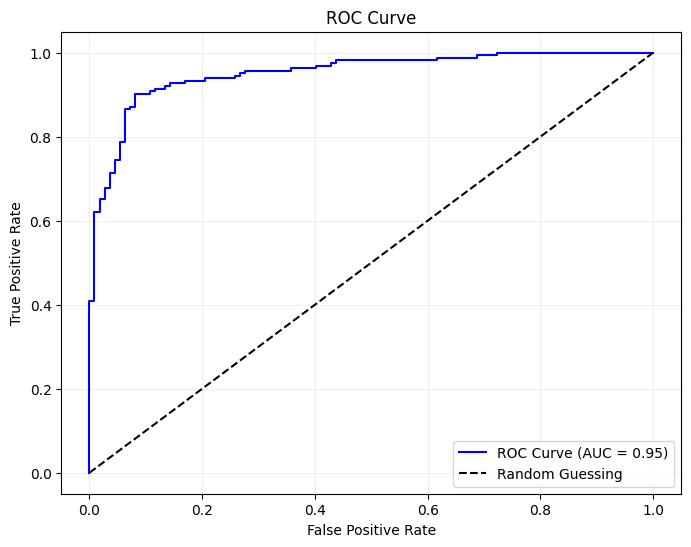

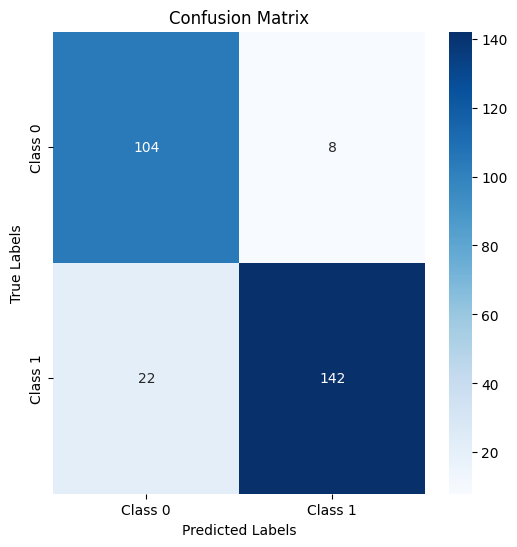

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("/kaggle/input/heart-failure-prediction/heart.csv")

# Convert object columns to categorical
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_columns:
    df[col] = df[col].astype('category')

# Separate features and target
X = df.drop(columns='HeartDisease')
y = df['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------------------
# GridSearch for XGBoost
# ------------------------------------
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', enable_categorical=True)

xgb_param_grid = {
    'n_estimators': [5, 10, 20, 50 ,100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [1e-4, 1e-3, 1e-2, 0.1,1], 
    'subsample': [0.5, 0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=3, scoring='accuracy', verbose=1)
xgb_grid.fit(X_train, y_train)

# Best XGBoost model
xgb_best_model = xgb_grid.best_estimator_
xgb_predictions = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Best Params: {xgb_grid.best_params_}")
print(f"XGBoost Accuracy (Raw Data): {xgb_accuracy}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, xgb_predictions)
print("\nConfusion Matrix:")
print(conf_matrix)

# ROC-AUC Score
# ROC-AUC Score and Curve
if len(set(y_test)) == 2:  # Ensure binary classification
    y_pred_proba = xgb_best_model.predict_proba(X_test)[:, 1]  # Probabilities of positive class
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nROC-AUC Score: {roc_auc}")

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="blue")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    roc_curve_path = "roc_curve_nn.png"
    plt.savefig(roc_curve_path)
    print(f"ROC Curve saved as {roc_curve_path}")
    plt.show()


# Vẽ Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()